# DATA3406 - Individual Checkpoint 2

### CC01 - Group 2 - "Do they get at least 15 minutes of intense activity on most days of the week?"

https://github.sydney.edu.au/abaj5525/2024-DATA3406-CC01-Group2/wiki/Personal-Planning-and-Progress-%E2%80%90-SID-520479766

In [140]:
# 30/09/2024
# IDs explored for checkpoint 1
IDs = [4020332650, 4057192912, 4319703577]

# ID explored in checkpoint 2
ID = 4319703577

As discussed with the group, I will analyse this individual's data by looking at if they get at least 15 continuous minutes of intense activity defined by the threshold of 125 steps/mins on most days of the week.

Assistance received:

- Reused code from Individual Checkpoint 1
- https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior
- https://www.geeksforgeeks.org/adding-new-column-to-existing-dataframe-in-pandas/

## Analysis of Driving Question

### Loading Data

The necessary libraries will be loaded and relevant data files read in. Pandas will be used to read in the data to aid in data cleaning. The data will be filtered to only contain the data for the assigned ID. Each column within the dataframe should be numeric, with one datetime column representing the date/time the data was recorded.

In [141]:
# 30/09/2024 3pm - 3:15pm
# Loading libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches

# Removing SettingWithCopyWarning
pd.options.mode.chained_assignment = None

# Reading in data file - minute step counts file
minutes = pd.read_csv("minuteStepsWide_merged.csv")

# Filtering dataset to only contain information for the ID explored, making new datasets so full dataset preserved
minutes_filtered = minutes.loc[minutes['Id'] == ID]

# Investigate data types of each column
print("Minutes dataset data types:")
print(minutes_filtered.dtypes)

# It looks like all of the columns are numeric, with the date/time column representing when the data was recorded being an object datatype
# For the minutes dataset, we need to split the ActivityHour column into new columns (date and date+time)
minutes_filtered['Date'] = minutes_filtered.ActivityHour.str.split('\\s+').str[0]

# Converting the columns in the minutes dataset to datetime data types
minutes_filtered['ActivityHour'] = pd.to_datetime(minutes_filtered['ActivityHour'], errors='coerce')
minutes_filtered['Date'] = pd.to_datetime(minutes_filtered['Date'], format = '%m/%d/%Y')

# Checking that the columns converted to datetime format correctly
print("\n" + "Minutes dataset data types after converting:")
print(minutes_filtered.dtypes)

Minutes dataset data types:
Id               int64
ActivityHour    object
Steps00          int64
Steps01          int64
Steps02          int64
                 ...  
Steps55          int64
Steps56          int64
Steps57          int64
Steps58          int64
Steps59          int64
Length: 62, dtype: object

Minutes dataset data types after converting:
Id                       int64
ActivityHour    datetime64[ns]
Steps00                  int64
Steps01                  int64
Steps02                  int64
                     ...      
Steps56                  int64
Steps57                  int64
Steps58                  int64
Steps59                  int64
Date            datetime64[ns]
Length: 63, dtype: object


The columns have all been converted to the predicted type to assist with visualising and grouping the datasets in the analysis. 

### Answering the Driving Question for ID: 4319703577

#### Filtering to remove non-valid days

This individual was chosen to be analysed as they did not have any days with a zero-step count when analysed in individual checkpoint 1. They do have a few days which had a very low number of non-zero minutes, which may mean that some days have to be removed due to them not wearing the tracker long enough for it to be considered a valid day. We will define valid days to be those with a step count of 500 or more.

In [142]:
# 30/09/2024 3:15pm - 3:30pm
# Creating a variable which contains all of the columns which are step counts
steps_columns = minutes_filtered.iloc[:, 3:62]

# Creating a new column called daily steps which sums the step columns for each row/hour of the dataset
minutes_filtered['dailysteps'] = steps_columns.sum(axis=1)

# Grouping the dataset by date to produce the daily steps for each data in the dataset
minutes_filtered.groupby('Date')['dailysteps'].sum()

Date
2016-04-13     3514
2016-04-14    10054
2016-04-15     5623
2016-04-16     4593
2016-04-17       16
2016-04-18     2209
2016-04-19     8809
2016-04-20     8816
2016-04-21      501
2016-04-22     4463
2016-04-23     4816
2016-04-24     4029
2016-04-25     9152
2016-04-26     9755
2016-04-27    10656
2016-04-28    10565
2016-04-29     7943
2016-04-30     8107
2016-05-01     1245
2016-05-02     8972
2016-05-03     9468
2016-05-04    10265
2016-05-05    13401
2016-05-06     9225
2016-05-07     7729
2016-05-08     3619
2016-05-09    10261
2016-05-10     9364
2016-05-11     9029
2016-05-12       17
Name: dailysteps, dtype: int64

There are two days within the dataset where the individual has less than 500 daily steps, so we will remove these days as they seem to not have worn the tracker enough on those days to consider the step counts to be valid.

In [143]:
# 30/09/2024 3:30pm - 3:45pm

# Creating a dataset with the daily steps column grouped by date
daily_steps = minutes_filtered.groupby('Date')['dailysteps'].sum().reset_index()

# Creating a list of valid dates where daily steps are >= 500
valid_dates = daily_steps[daily_steps['dailysteps'] >= 500]['Date'].tolist()

# Filtering the original dataset to only include rows with valid dates
valid_minutes = minutes_filtered[minutes_filtered['Date'].isin(valid_dates)]

# Checking the new dataset to ensure that the values less than 500 were removed correctly
valid_minutes.groupby('Date')['dailysteps'].sum()

Date
2016-04-13     3514
2016-04-14    10054
2016-04-15     5623
2016-04-16     4593
2016-04-18     2209
2016-04-19     8809
2016-04-20     8816
2016-04-21      501
2016-04-22     4463
2016-04-23     4816
2016-04-24     4029
2016-04-25     9152
2016-04-26     9755
2016-04-27    10656
2016-04-28    10565
2016-04-29     7943
2016-04-30     8107
2016-05-01     1245
2016-05-02     8972
2016-05-03     9468
2016-05-04    10265
2016-05-05    13401
2016-05-06     9225
2016-05-07     7729
2016-05-08     3619
2016-05-09    10261
2016-05-10     9364
2016-05-11     9029
Name: dailysteps, dtype: int64

#### Plotting the daily steps data to visualise activity

We will plot the daily steps for the dates that are left after filtering to visualise the dates that we will be looking at for analysis. We will also highlight the weekends to understand what data we are using.

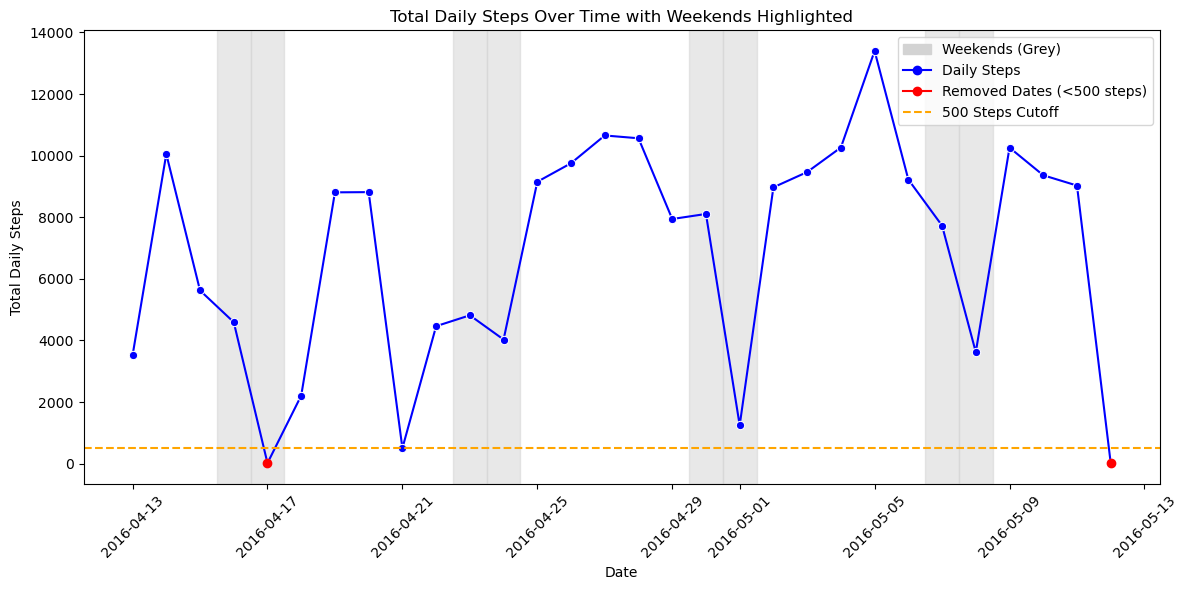

In [144]:
# 30/09/2024 4pm - 4:30pm

# Extract day of the week from the 'Date' column and classify as weekday or weekend
daily_steps['day_of_week'] = daily_steps['Date'].dt.day_name()
daily_steps['is_weekend'] = daily_steps['day_of_week'].isin(['Saturday', 'Sunday'])

# Plotting the daily steps with a continuous x-axis (even with missing dates)
plt.figure(figsize=(12, 6))

# Shading the weekends
for index, row in daily_steps.iterrows():
    if row['is_weekend']:
        plt.axvspan(row['Date'] - pd.Timedelta(days=0.5), 
                    row['Date'] + pd.Timedelta(days=0.5), 
                    color='lightgray', alpha=0.5)

# Plot the total daily steps with a continuous line
sns.lineplot(x='Date', y='dailysteps', data=daily_steps, marker='o', label='Daily Steps', color='blue')

# Add a horizontal line to indicate the 500 steps cutoff
plt.axhline(y=500, color='orange', linestyle='--')

# Highlight the removed dates (daily steps < 500) for visual distinction
removed_steps = daily_steps[daily_steps['dailysteps'] < 500]
plt.scatter(removed_steps['Date'], removed_steps['dailysteps'], color='red', label='Removed Dates (<500 steps)', zorder=5)

# Create a custom legend entry for the weekend shading
weekend_patch = mpatches.Patch(color='lightgray', label='Weekends (Grey)')

# Customizing the legend
plt.legend(handles=[weekend_patch, plt.Line2D([], [], color='blue', marker='o', label='Daily Steps'), 
                    plt.Line2D([], [], color='red', marker='o', label='Removed Dates (<500 steps)'),
                      plt.Line2D([], [], color='orange', linestyle='--', label='500 Steps Cutoff')])

# Formatting the plot
plt.title('Total Daily Steps Over Time with Weekends Highlighted')
plt.xlabel('Date')
plt.ylabel('Total Daily Steps')
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

It seems that for this individual we have a continuous range of dates from Wednesday to Saturday and then 3.5 weeks of continuous dates starting from a Monday to ending on a Wednesday.

#### Counting the number of minutes per day which meet the 125 step/min threshold

The individual analysed often has 10,000 or more steps, which would suggest that they are quite active, so it is assumed that they could meet the threshold for intense activity.

In [145]:
# 30/09/2024 5:45pm - 6pm

# Set step threshold to 125 as assigned by group
step_threshold = 125
steps_columns = valid_minutes.iloc[:, 3:62]
threshold = steps_columns >= step_threshold

# Count how many minutes within the hour (not-continuous) are greater than or equal to the threshold
hourly_threshold = threshold.sum(axis=1)

valid_minutes = minutes_filtered[minutes_filtered['Date'].isin(valid_dates)]
valid_minutes.insert(2, "HourlyThreshold", hourly_threshold)

# Show how many minutes are greater than or equal to the threshold (not-continuous)
valid_minutes.groupby('Date')['HourlyThreshold'].sum('HourlyThreshold')

Date
2016-04-13     0
2016-04-14     1
2016-04-15     0
2016-04-16     0
2016-04-18     1
2016-04-19     0
2016-04-20     0
2016-04-21     0
2016-04-22     0
2016-04-23     0
2016-04-24     0
2016-04-25     0
2016-04-26     0
2016-04-27     0
2016-04-28     2
2016-04-29     0
2016-04-30     0
2016-05-01     0
2016-05-02     1
2016-05-03     0
2016-05-04     1
2016-05-05    12
2016-05-06     2
2016-05-07     0
2016-05-08     0
2016-05-09     0
2016-05-10     0
2016-05-11     0
Name: HourlyThreshold, dtype: int64

Across this person's data, the day with the most intense activity as defined by a 125 step/min threshold has only 13 minutes of intense activity. This suggests that while this person is quite active and often achieves 10,000 steps per day, they may not engage in much intensive activity, and prefer to engage in moderate walking.

#### Finding the longest continuous activity which this individual completed

It is assumed that this individual will not have very long continuous intense activity as they only had one day within the previous analysis with more than 2 minutes in the whole day of intense activity.

In [146]:
# 7/10/2024 1pm - 1:30pm

# Setting step threshold to 125 as assigned by group
step_threshold = 125
steps_columns = valid_minutes.iloc[:, 3:63]
threshold = steps_columns >= step_threshold  # Apply the threshold to create a boolean dataframe

# Function to find the longest continuous run of minutes above the threshold (across hours)
def longest_run_across_day(df):
    longest_run = 0  # Track the longest overall run
    current_run = 0  # Track the current continuous run across hours

    for index, row in df.iterrows():  # Loop over each row (hour)
        bool_array = row.values
        # Loop over the boolean array for each minute (after applying the threshold)
        for val in bool_array:
            if val:  # If it's above the threshold (True)
                current_run += 1
            else:  # If it's below the threshold (False), reset the current run
                longest_run = max(longest_run, current_run)
                current_run = 0
        
        # After each row update the longest run found so far
        longest_run = max(longest_run, current_run)

    return longest_run

# Loop over the dataframe to compute the longest continuous run across hours
longest_runs_by_date = []
for date, group in threshold.groupby(valid_minutes['Date']):  # Group by 'Date'
    longest_run = longest_run_across_day(group)  # Apply function to group of hours in a day
    longest_runs_by_date.append({'Date': date, 'LongestContinuousRun': longest_run})

# Convert the results to a dataframe
daily_runs_df = pd.DataFrame(longest_runs_by_date)
print(daily_runs_df)

         Date  LongestContinuousRun
0  2016-04-13                     0
1  2016-04-14                     1
2  2016-04-15                     0
3  2016-04-16                     0
4  2016-04-18                     1
5  2016-04-19                     0
6  2016-04-20                     0
7  2016-04-21                     0
8  2016-04-22                     0
9  2016-04-23                     0
10 2016-04-24                     0
11 2016-04-25                     0
12 2016-04-26                     0
13 2016-04-27                     0
14 2016-04-28                     1
15 2016-04-29                     0
16 2016-04-30                     0
17 2016-05-01                     0
18 2016-05-02                     1
19 2016-05-03                     0
20 2016-05-04                     1
21 2016-05-05                    11
22 2016-05-06                     1
23 2016-05-07                     0
24 2016-05-08                     0
25 2016-05-09                     0
26 2016-05-10               

The longest continuous intense activity which this individual completed was for 11 minutes. This suggests that this individual does not engage in much intense activity and would not meet the requirements of the driving question - "Do they get at least 15 minutes of intense activity on most days of the week?".

#### Finding for each consecutive 7-day window, how many days meet the threshold

We have seen previously that no days meet the threshold, but when looking at other ID's it is important to define the results in terms of the question, but we will see that 0 meet the threshold for this individual.

In [150]:
# 7/10/2024 4pm - 5:45pm

# Sort the daily data by date
daily_runs_df = daily_runs_df.sort_values(by='Date')

# Function to check if a window has exactly 7 consecutive days
def is_continuous_week(sub_df):
    start_date = sub_df['Date'].iloc[0]
    end_date = sub_df['Date'].iloc[-1]
    return (end_date - start_date).days == 6  # A 7-day period should span exactly 6 days

# Function to count qualifying days (days with at least 15 continuous minutes of activity)
def count_qualifying_days(sub_df):
    return (sub_df['LongestContinuousRun'] >= 15).sum()

# List to store results for each 7-day window
rolling_weeks = []

# Iterate through the dataframe with a rolling window of 7 rows (7 days)
for i in range(len(daily_runs_df) - 6):
    # Select a 7-day window
    sub_df = daily_runs_df.iloc[i:i+7]
    
    # Check if the window spans exactly 7 consecutive days
    if is_continuous_week(sub_df):
        # Count how many days in the window meet the 15-minute activity threshold
        qualifying_days = count_qualifying_days(sub_df)
        
        # Append the result with the start and end dates of the window
        rolling_weeks.append({
            'Start': sub_df['Date'].iloc[0],
            'End': sub_df['Date'].iloc[-1],
            'QualifyingDays': qualifying_days
        })

# Convert the results into a dataframe
rolling_weeks_df = pd.DataFrame(rolling_weeks)
print(rolling_weeks_df)

        Start        End  QualifyingDays
0  2016-04-18 2016-04-24               0
1  2016-04-19 2016-04-25               0
2  2016-04-20 2016-04-26               0
3  2016-04-21 2016-04-27               0
4  2016-04-22 2016-04-28               0
5  2016-04-23 2016-04-29               0
6  2016-04-24 2016-04-30               0
7  2016-04-25 2016-05-01               0
8  2016-04-26 2016-05-02               0
9  2016-04-27 2016-05-03               0
10 2016-04-28 2016-05-04               0
11 2016-04-29 2016-05-05               0
12 2016-04-30 2016-05-06               0
13 2016-05-01 2016-05-07               0
14 2016-05-02 2016-05-08               0
15 2016-05-03 2016-05-09               0
16 2016-05-04 2016-05-10               0
17 2016-05-05 2016-05-11               0


As predicted, for each consecutive 7 day period, 0 days qualify.

#### Visualising the results in terms of the question

As seen above, there will be 0 days that meet the threshold for this individual, but we should visualise this.

Empty DataFrame
Columns: [Start, End, QualifyingDays]
Index: []


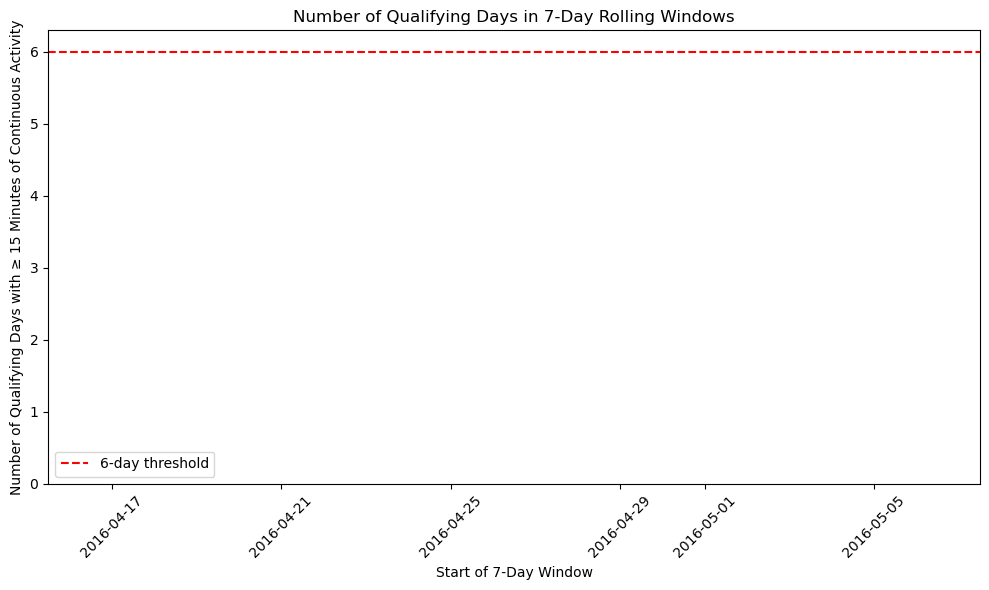

In [148]:
# 7/10/2024 5:45pm - 6pm

# Filter to find 7-day windows with at least 6 qualifying days
qualifying_weeks = rolling_weeks_df[rolling_weeks_df['QualifyingDays'] >= 6]
print(qualifying_weeks)

# Plotting the qualifying days per 7-day window
plt.figure(figsize=(10, 6))
plt.bar(rolling_weeks_df['Start'], rolling_weeks_df['QualifyingDays'], width=3, color='lightblue', align='center')

# Highlight weeks that meet the 6-day threshold
for index, row in rolling_weeks_df.iterrows():
    if row['QualifyingDays'] >= 6:
        plt.bar(row['Start'], row['QualifyingDays'], width=3, color='green', align='center')

# Add a horizontal line for the 6-day threshold
plt.axhline(y=6, color='r', linestyle='--', label='6-day threshold')

plt.title('Number of Qualifying Days in 7-Day Rolling Windows')
plt.xlabel('Start of 7-Day Window')
plt.ylabel('Number of Qualifying Days with ≥ 15 Minutes of Continuous Activity')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

For this driving question, it can be seen that this individual does not meet the threshold of 15-minutes of intense activity for most days of the week.